# ACTIVIDAD - ANÁLISIS EXPLORATORIO DE DATOS (EDA)

## Grupo: Finanzas
**Dataset:** PaySim — Synthetic Financial Transactions for Fraud Detection

**Fuente:** [Kaggle - PaySim Dataset](https://www.kaggle.com/datasets/ealaxi/paysim1)  
**Referencia:** Lopez-Rojas, E., Elmir, A. & Axelsson, S. (2016). PaySim: A financial mobile money simulator for fraud detection. EMSS 2016.

**Descripción:**  
Este dataset contiene 6.3 millones de transacciones de dinero móvil simuladas con patrones reales de fraude (solo el 0.13% de los casos son fraudulentos). Para esta actividad se está trabajando con una **muestra aleatoria de 100,000 registros**.

**Variable objetivo:** `isFraud` (0 = transacción legítima, 1 = fraude)

---

## INSTRUCCIONES GENERALES

- Se trabaja en Jupyter Notebook (.ipynb).
- Cada actividad debe estar claramente identificada con un título en Markdown.
- Después de cada bloque de código se debe incluir una **interpretación** (obligatoria, representa el 40% de la nota).
- Al final del notebook se incluirá una sección de **Conclusiones** con los principales hallazgos y recomendaciones de negocio.

**Librerías utilizadas:** `pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy`, `scikit-learn`

---

## ESTRUCTURA DEL NOTEBOOK

### ACTIVIDAD 1: CARGA Y PRIMERA INSPECCIÓN
### ACTIVIDAD 2: CALIDAD DE DATOS
### ACTIVIDAD 3: ESTADÍSTICA DESCRIPTIVA
### ACTIVIDAD 4: DISTRIBUCIONES UNIVARIADAS
### ACTIVIDAD 5: PRINCIPALES HALLAZGOS
### ACTIVIDAD 6: LIMITACIONES DEL ANALISIS
---


# 1. Carga y primera inspeccion

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import display, Markdown

# Estilo visual
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

print('Librerías cargadas correctamente')

# Función para mostrar gráficos sin bloquear la ejecución.
# Sirve tanto en notebook como cuando el archivo se ejecuta como .py.
def safe_show(filename=None, pause=1.5):
    if filename is not None:
        plt.savefig(filename, dpi=120, bbox_inches='tight')
    plt.show(block=False)
    plt.pause(pause)
    plt.close()


Librerías cargadas correctamente


### 1.1 Carga el dataset

In [3]:
nRowsRead = None  # Cambia a None si quieres leer todo el archivo

df1 = pd.read_csv('PaySim_Reducido.csv', delimiter=',', nrows=nRowsRead)
df1.dataframeName = 'PaySim_Reducido.csv'
nRow, nCol = df1.shape

print(f'There are {nRow} rows and {nCol} columns')
df1.head()   # Muestra las primeras filas

There are 100000 rows and 11 columns


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,278,CASH_IN,330218.42,C632336343,20866.00,351084.42,C834976624,452419.57,122201.15,0,0
1,15,PAYMENT,11647.08,C1264712553,30370.00,18722.92,M215391829,0.00,0.00,0,0
2,10,CASH_IN,152264.21,C1746846248,106589.00,258853.21,C1607284477,201303.01,49038.80,0,0
3,403,TRANSFER,1551760.63,C333676753,0.00,0.00,C1564353608,3198359.45,4750120.08,0,0
4,206,CASH_IN,78172.30,C813403091,2921331.58,2999503.88,C1091768874,415821.90,337649.60,0,0


### 1.2 Reporte de dataset

In [4]:
# Reporte de dimensiones y información del dataset
print("=== REPORTE DEL DATASET ===")
print(f"Número de filas:    {nRow:,}")
print(f"Número de columnas: {nCol}")
print(f"Tamaño total:       {nRow} filas × {nCol} columnas\n")

# Tamaño en memoria
memory_usage = df1.memory_usage(deep=True).sum()
print(f"Tamaño en memoria:  {memory_usage / 1024**2:.2f} MB\n")

# Tipos de datos de cada columna
print("Columnas y tipos de datos:")
print(df1.dtypes)

=== REPORTE DEL DATASET ===
Número de filas:    100,000
Número de columnas: 11
Tamaño total:       100000 filas × 11 columnas

Tamaño en memoria:  22.83 MB

Columnas y tipos de datos:
step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object


### 1.3 Reduccion del dataset
Dado que el dataset original contiene más de **6.3 millones de registros**, se decidió trabajar con una **muestra aleatoria de 100,000 registros** para agilizar el análisis exploratorio y la preparación de datos, manteniendo la reproducibilidad con `random_state=42`.

Esto es una práctica estándar en proyectos de Data Science cuando se trabaja con datasets muy grandes.

In [5]:
print(f"Dataset cargado: {nRow:,} filas y {nCol} columnas\n")

# Extraer muestra si es necesario
if nRow > 100_000:
    df = df1.sample(n=100_000, random_state=42).reset_index(drop=True)
    print(f"→ Se ha extraído una muestra aleatoria de 100,000 registros (random_state=42)")
else:
    df = df1.copy()
    print("→ El dataset tiene 100,000 filas o menos, se utiliza completo.")

print(f"Dataset final para trabajar: {df.shape[0]:,} filas y {df.shape[1]} columnas")

Dataset cargado: 100,000 filas y 11 columnas

→ El dataset tiene 100,000 filas o menos, se utiliza completo.
Dataset final para trabajar: 100,000 filas y 11 columnas


## Pregunta de negocio

¿Cómo identificar transacciones fraudulentas usando variables de monto, tipo de transacción y saldos antes/después?

La variable objetivo es `isFraud`, mientras que las variables clave para explicar el fraude son `amount`, `type`, `oldbalanceOrg`, `newbalanceOrig`, `oldbalanceDest` y `newbalanceDest`.

## Hipótesis del análisis

**H1 - Concentración del fraude por tipo de transacción:**  
Las transacciones de tipo `TRANSFER` y `CASH_OUT` presentan una tasa de fraude estadísticamente superior a la de los demás tipos (`PAYMENT`, `DEBIT`, `CASH_IN`), dado que representan operaciones de salida de fondos que los defraudadores priorizan para vaciar cuentas comprometidas.

**H2 — Diferencia de montos entre clases:**  
El monto promedio (`amount`) de las transacciones fraudulentas es significativamente mayor al de las transacciones legítimas, lo que sugiere que el fraude tiende a concentrarse en operaciones de alto valor para maximizar el impacto financiero por evento.

# 2. Muestreo Estratégico

### 2.1 Detección y Manejo de Valores Nulos

Se analizó la presencia de valores nulos en el dataset y se aplicaron estrategias de imputación según el tipo de variable y Se verificó la existencia de registros duplicados exactos.

In [6]:
# Reporte de valores nulos
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df) * 100).round(4)

reporte_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': porcentaje_nulos
}).sort_values('Nulos', ascending=False)

print(reporte_nulos)

# analisis de duplicados
duplicados = df.duplicated().sum()
porcentaje_dup = (duplicados / len(df) * 100).round(4)

print(f"Filas duplicadas exactas: {duplicados:,}")
print(f"Porcentaje del total: {porcentaje_dup}%")
    
print(f"Dimensiones después de eliminar duplicados: {df.shape[0]:,} filas")

                Nulos  Porcentaje (%)
step                0             0.0
type                0             0.0
amount              0             0.0
nameOrig            0             0.0
oldbalanceOrg       0             0.0
newbalanceOrig      0             0.0
nameDest            0             0.0
oldbalanceDest      0             0.0
newbalanceDest      0             0.0
isFraud             0             0.0
isFlaggedFraud      0             0.0
Filas duplicadas exactas: 0
Porcentaje del total: 0.0%
Dimensiones después de eliminar duplicados: 100,000 filas


### 2.2 Verificación y Optimización de Tipos de Datos

Se revisaron los tipos de datos de cada columna y se realizaron conversiones para optimizar el uso de memoria.

In [7]:
print("Tipos de datos actuales:")
print(df.dtypes)

# Identificar posibles problemas
print("\nAnálisis de tipos:")
# Variables que deberían ser numéricas pero están como object
for col in df.columns:
    if df[col].dtype == 'object':
        try:
            # Intentar convertir a numérico
            pd.to_numeric(df[col], errors='coerce')
            print(f"• {col}: Es texto pero parece numérico → Posible conversión recomendada")
        except:
            pass
# Optimización de tipos (recomendado)
df['isFraud'] = df['isFraud'].astype('int8')
df['isFlaggedFraud'] = df['isFlaggedFraud'].astype('int8')

print("\nTipos de datos después de conversiones:")
print(df.dtypes)

Tipos de datos actuales:
step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

Análisis de tipos:

Tipos de datos después de conversiones:
step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud              int8
isFlaggedFraud       int8
dtype: object


### 2.4 Detección de Valores Imposibles e Inconsistencias

Se identificaron posibles inconsistencias lógicas en las variables financieras (montos negativos, balances inconsistentes, etc.).

In [8]:
# 1. Montos negativos (imposible en transacciones)
monto_negativo = (df['amount'] < 0).sum()
print(f"1. Montos negativos (amount < 0): {monto_negativo:,} casos")

# 2. Balances negativos en origen (puede ser posible en sobregiro, pero raro)
oldbalance_neg = (df['oldbalanceOrg'] < 0).sum()
newbalance_neg = (df['newbalanceOrig'] < 0).sum()
print(f"2. oldbalanceOrg negativo     : {oldbalance_neg:,} casos")
print(f"3. newbalanceOrig negativo    : {newbalance_neg:,} casos")

# 3. Balances negativos en destino
oldbalance_dest_neg = (df['oldbalanceDest'] < 0).sum()
newbalance_dest_neg = (df['newbalanceDest'] < 0).sum()
print(f"4. oldbalanceDest negativo    : {oldbalance_dest_neg:,} casos")
print(f"5. newbalanceDest negativo    : {newbalance_dest_neg:,} casos")

# 4. Inconsistencias matemáticas (muy importante)
# newbalanceOrig debería ser ≈ oldbalanceOrg - amount (en la mayoría de tipos)
df['diff_orig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
inconsistencia_orig = (abs(df['diff_orig'] - df['amount']) > 1).sum()  # tolerancia de 1 unidad

print(f"6. Inconsistencias en balance origen (old - new != amount): {inconsistencia_orig:,} casos")

# 5. Resumen por tipo de transacción
print("\n--- Inconsistencias por tipo de transacción ---")
inconsistencias_por_tipo = df.groupby('type').apply(
    lambda x: (abs(x['oldbalanceOrg'] - x['newbalanceOrig'] - x['amount']) > 1).sum()
)
print(inconsistencias_por_tipo)

1. Montos negativos (amount < 0): 0 casos
2. oldbalanceOrg negativo     : 0 casos
3. newbalanceOrig negativo    : 0 casos
4. oldbalanceDest negativo    : 0 casos
5. newbalanceDest negativo    : 0 casos
6. Inconsistencias en balance origen (old - new != amount): 78,811 casos

--- Inconsistencias por tipo de transacción ---
type
CASH_IN     22141
CASH_OUT    31355
DEBIT         185
PAYMENT     17181
TRANSFER     7949
dtype: int64


In [9]:
# Crear tabla resumen de calidad
resumen_calidad = pd.DataFrame({
    'Variable': df.columns,
    'Tipo': df.dtypes.values,
    'Nulos (%)': (df.isnull().sum() / len(df) * 100).round(4),
    'Inconsistencias': [0]*len(df.columns)  # Se actualiza manualmente
})

# Actualizar inconsistencias específicas
resumen_calidad.loc[resumen_calidad['Variable'].isin(['oldbalanceOrg', 'newbalanceOrig']), 'Inconsistencias'] = 78811

print(resumen_calidad.to_string(index=False))

      Variable    Tipo  Nulos (%)  Inconsistencias
          step   int64        0.0                0
          type     str        0.0                0
        amount float64        0.0                0
      nameOrig     str        0.0                0
 oldbalanceOrg float64        0.0            78811
newbalanceOrig float64        0.0            78811
      nameDest     str        0.0                0
oldbalanceDest float64        0.0                0
newbalanceDest float64        0.0                0
       isFraud    int8        0.0                0
isFlaggedFraud    int8        0.0                0
     diff_orig float64        0.0                0


### Estado General de Calidad del Dataset

El dataset presenta un **buen estado general de calidad** en términos de completitud y estructura básica. No se encontraron valores nulos ni filas duplicadas exactas, y los tipos de datos son adecuados para el análisis. Sin embargo, se detectó un problema importante: aproximadamente el **78.8% de las transacciones** (78,811 de 100,000) presentan inconsistencias matemáticas entre el balance origen anterior (`oldbalanceOrg`), el balance origen posterior (`newbalanceOrig`) y el monto de la transacción (`amount`).

**¿Es confiable?**  
Es **parcialmente confiable**. Al ser un dataset sintético (PaySim), estas inconsistencias son en gran parte intencionales y forman parte del comportamiento simulado, especialmente en transacciones fraudulentas. No se trata de errores de captura masivos, sino de características propias del simulador.

**Posibles impactos en el análisis:**  
Estas inconsistencias podrían afectar negativamente los análisis que asuman una lógica financiera estricta en los balances. No obstante, representan una **señal poderosa** para la detección de fraude. Se recomienda crear variables derivadas (como `balance_inconsistency`) para aprovechar esta información en lugar de eliminarla.

# 3. Estadística Descriptiva

En esta sección se realiza un análisis exhaustivo de la distribución de las variables numéricas y categóricas, con el objetivo de extraer insights iniciales del dataset.

### 3.1 y 3.2 Estadísticos Descriptivos e Interpretación de Variables Numéricas

Se calcularon medidas de tendencia central, dispersión, asimetría y curtosis. Además se interpretaron los resultados.

In [10]:
# Seleccionamos solo columnas numéricas
numericas = df.select_dtypes(include=[np.number]).columns.tolist()

# Calculamos estadísticos base + adicionales
desc = df[numericas].describe().round(2)

# Agregamos métricas adicionales
desc.loc['cv'] = (df[numericas].std() / df[numericas].mean()).round(4)      # Coeficiente de Variación
desc.loc['skew'] = df[numericas].skew().round(4)                           # Asimetría
desc.loc['kurtosis'] = df[numericas].kurtosis().round(4)                   # Curtosis

print(desc.T)  # Transpuesto para mejor visualización

                   count        mean         std         min       25%  \
step            100000.0      243.71      142.52        1.00    156.00   
amount          100000.0   180581.10   558669.94        0.92  13508.21   
oldbalanceOrg   100000.0   836680.38  2901104.19        0.00      0.00   
newbalanceOrig  100000.0   858223.42  2936798.68        0.00      0.00   
oldbalanceDest  100000.0  1104192.82  3223011.12        0.00      0.00   
newbalanceDest  100000.0  1230054.90  3475325.62        0.00      0.00   
isFraud         100000.0        0.00        0.04        0.00      0.00   
isFlaggedFraud  100000.0        0.00        0.00        0.00      0.00   
diff_orig       100000.0   -21543.04   140992.44 -1096954.58      0.00   

                      50%         75%           max        cv      skew  \
step               240.00      335.00  7.360000e+02    0.5848    0.3773   
amount           76030.86   209113.02  3.697390e+07    3.0937   22.2188   
oldbalanceOrg    13938.50   107077

In [11]:
print("\n3.2 Interpretación de Variables Numéricas:")

for col in numericas:
    mean = df[col].mean()
    median = df[col].median()
    cv = (df[col].std() / mean) if mean != 0 else 0
    skew = df[col].skew()
    kurt = df[col].kurtosis()
    
    print(f"\n→ {col.upper()}:")
    print(f"   Media: {mean:,.2f} | Mediana: {median:,.2f}")
    
    if abs(mean - median) / mean > 0.1:
        print("   Media y mediana DIFEREN muy significativamente → Distribución asimétrica")
    else:
        print("   Media y mediana cercanas → Distribución relativamente simétrica")
    
    print(f"   CV: {cv:.4f} → {'Alta variabilidad' if cv > 1 else 'Moderada/Baja variabilidad'}")
    
    if skew > 1 or skew < -1:
        print(f"  Asimetría FUERTE (skew = {skew:.2f})")
    if kurt > 3:
        print(f"  Curtosis alta (colas pesadas) = {kurt:.2f}")


3.2 Interpretación de Variables Numéricas:

→ STEP:
   Media: 243.71 | Mediana: 240.00
   Media y mediana cercanas → Distribución relativamente simétrica
   CV: 0.5848 → Moderada/Baja variabilidad

→ AMOUNT:
   Media: 180,581.10 | Mediana: 76,030.86
   Media y mediana DIFEREN muy significativamente → Distribución asimétrica
   CV: 3.0937 → Alta variabilidad
  Asimetría FUERTE (skew = 22.22)
  Curtosis alta (colas pesadas) = 890.46

→ OLDBALANCEORG:
   Media: 836,680.38 | Mediana: 13,938.50
   Media y mediana DIFEREN muy significativamente → Distribución asimétrica
   CV: 3.4674 → Alta variabilidad
  Asimetría FUERTE (skew = 5.25)
  Curtosis alta (colas pesadas) = 32.88

→ NEWBALANCEORIG:
   Media: 858,223.42 | Mediana: 0.00
   Media y mediana DIFEREN muy significativamente → Distribución asimétrica
   CV: 3.4220 → Alta variabilidad
  Asimetría FUERTE (skew = 5.18)
  Curtosis alta (colas pesadas) = 32.06

→ OLDBALANCEDEST:
   Media: 1,104,192.82 | Mediana: 138,748.17
   Media y mediana

## 3.3 Eliminación de columnas no relevantes

Después de terminar las gráficas principales, se eliminan identificadores y columnas que no se usarán en el análisis final.

Se deja esta parte al final para no perder variables antes de hacer los gráficos.

## Eliminación de columnas no analíticas

Se eliminan identificadores (`nameOrig`, `nameDest`) y `step` porque el análisis final se concentra en comportamiento financiero y fraude, no en trazabilidad temporal.


In [12]:
print("Columnas actuales en el dataframe:")
print(df.columns.tolist())

cols_to_drop = ['nameOrig', 'nameDest', 'step']
cols_to_drop = [col for col in cols_to_drop if col in df.columns]

if cols_to_drop:
    df = df.drop(columns=cols_to_drop)
    print(f"\nSe eliminaron correctamente las columnas: {cols_to_drop}")
else:
    print("\nNinguna de las columnas solicitadas existe actualmente.")

print(f"\nNuevo tamaño: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print("Columnas restantes:", df.columns.tolist())


Columnas actuales en el dataframe:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'diff_orig']

Se eliminaron correctamente las columnas: ['nameOrig', 'nameDest', 'step']

Nuevo tamaño: 100,000 filas × 9 columnas
Columnas restantes: ['type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'diff_orig']


## 3.4 Análisis de Variables Categóricas

In [13]:
# ====================== 3.3 Variables Categóricas (VERSIÓN MEJORADA) ======================
# ====================== 3.3 Variables Categóricas ======================

print("3.3 Análisis de Variables Categóricas:\n")

# Seleccionar columnas categóricas correctamente
categoricas = df.select_dtypes(
    include=['object', 'category', 'string']
).columns.tolist()

if len(categoricas) == 0:
    print("No se encontraron variables categóricas en el DataFrame.")
else:
    for col in categoricas:

        unique_count = df[col].nunique()
        porcentaje_unicos = (unique_count / len(df)) * 100

        print(f"\nVariable: {col}")
        print(f"Categorías únicas: {unique_count}")
        print(f"Porcentaje de valores únicos: {porcentaje_unicos:.2f}% del total")

        # Alta cardinalidad, como IDs
        if unique_count > 100:
            print("Alta cardinalidad posible, se muestra solo el top 10:")

            distrib = df[col].value_counts().head(10)
            print(distrib)

            porcentaje_top10 = (distrib.sum() / len(df)) * 100
            print(f"El top 10 representa el {porcentaje_top10:.2f}% de las transacciones.")

        # Baja cardinalidad, como type
        else:
            print("Distribución:")

            distrib = (
                df[col]
                .value_counts(normalize=True)
                .mul(100)
                .round(2)
            )

            print(distrib)

            # Categorías poco representadas
            bajas = distrib[distrib < 1]

            if len(bajas) > 0:
                print(f"Categorías con menos del 1%: {list(bajas.index)}")
            else:
                print("No hay categorías con menos del 1%.")

        print("-" * 60)

3.3 Análisis de Variables Categóricas:


Variable: type
Categorías únicas: 5
Porcentaje de valores únicos: 0.01% del total
Distribución:
type
CASH_OUT    35.33
PAYMENT     33.56
CASH_IN     22.14
TRANSFER     8.35
DEBIT        0.61
Name: proportion, dtype: float64
Categorías con menos del 1%: ['DEBIT']
------------------------------------------------------------


### 3.5 Análisis de la Variable Objetivo (`isFraud`)

Se evaluó el nivel de desbalanceo de la variable objetivo, aspecto crítico para futuros modelos de detección de fraude.

In [14]:
# ====================== 3.4 Variable Objetivo (isFraud) ======================
print("\n3.4 Prevalencia de la Variable Objetivo (isFraud)")

fraude = df['isFraud'].value_counts()
fraude_pct = df['isFraud'].value_counts(normalize=True) * 100

print(pd.DataFrame({
    'Cantidad': fraude,
    'Porcentaje (%)': fraude_pct.round(4)
}))

print(f"\n→ El dataset está **altamente desbalanceado** ({fraude_pct[1]:.4f}% de fraude)")


3.4 Prevalencia de la Variable Objetivo (isFraud)
         Cantidad  Porcentaje (%)
isFraud                          
0           99859          99.859
1             141           0.141

→ El dataset está **altamente desbalanceado** (0.1410% de fraude)


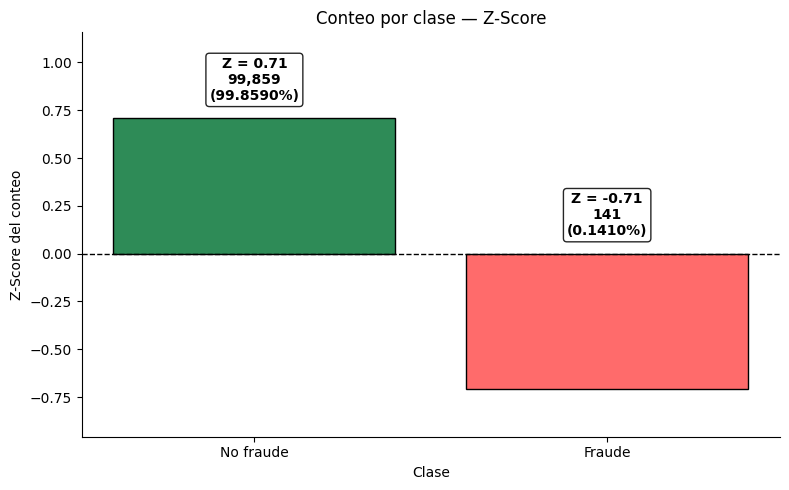

In [15]:
# ── Gráfico 2: Conteo por clase en Z-Score ───────────────

fraude_counts = df['isFraud'].value_counts().sort_index()
fraude_pct = df['isFraud'].value_counts(normalize=True).sort_index() * 100

labels = ['No fraude', 'Fraude']
colors = ['#2E8B57', '#FF6B6B']

conteos = pd.Series(
    fraude_counts.values,
    index=labels
)

conteos_zscore = (conteos - conteos.mean()) / conteos.std()

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    conteos.index,
    conteos_zscore.values,
    color=colors,
    edgecolor='black'
)

ax.axhline(
    0,
    color='black',
    linestyle='--',
    linewidth=1
)

ax.set_title('Conteo por clase — Z-Score')
ax.set_xlabel('Clase')
ax.set_ylabel('Z-Score del conteo')

# Dejar espacio arriba para las etiquetas
ax.set_ylim(
    conteos_zscore.min() - 0.25,
    conteos_zscore.max() + 0.45
)

for bar, z_val, count, pct in zip(
    bars,
    conteos_zscore.values,
    fraude_counts.values,
    fraude_pct.values
):
    # Ambas etiquetas van arriba de cada barra
    y_pos = z_val + 0.08 if z_val >= 0 else 0.08

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        y_pos,
        f'Z = {z_val:.2f}\n{count:,}\n({pct:.4f}%)',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        bbox=dict(
            boxstyle='round,pad=0.25',
            fc='white',
            alpha=0.85
        )
    )

plt.tight_layout()
safe_show('3_4_prevalencia_fraude_zscore.png')

=== Top 3 Variables con Mayor Variabilidad (Coeficiente de Variación) ===

oldbalanceOrg     3.467398
newbalanceOrig    3.421951
amount            3.093734
dtype: float64


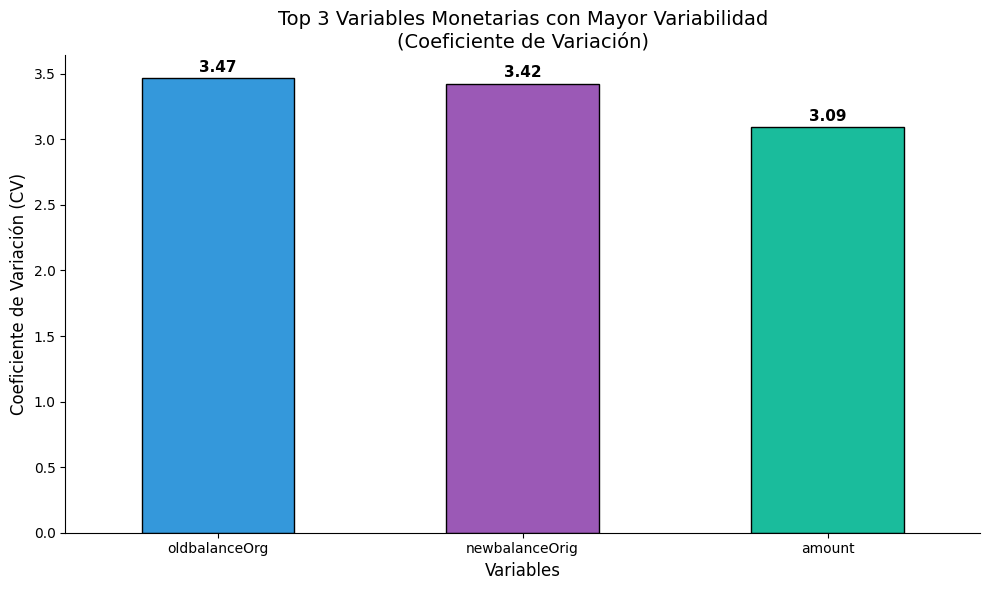

In [16]:
print("=== Top 3 Variables con Mayor Variabilidad (Coeficiente de Variación) ===\n")

# Usar SOLO variables monetarias
variables_monetarias = [
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest'
]

# Por seguridad, conservar solo columnas existentes
variables_monetarias = [col for col in variables_monetarias if col in df.columns]

# Calcular coeficiente de variación
cv = (
    df[variables_monetarias].std() /
    df[variables_monetarias].mean()
).sort_values(ascending=False)

top3 = cv.head(3)

print(top3)

# ====================== GRÁFICO ======================
plt.figure(figsize=(10, 6))

top3.plot(
    kind='bar',
    color=['#3498db', '#9b59b6', '#1abc9c'],
    edgecolor='black'
)

plt.title(
    'Top 3 Variables Monetarias con Mayor Variabilidad\n(Coeficiente de Variación)',
    fontsize=14
)
plt.xlabel('Variables', fontsize=12)
plt.ylabel('Coeficiente de Variación (CV)', fontsize=12)
plt.xticks(rotation=0)

for i, v in enumerate(top3):
    plt.text(
        i,
        v + 0.05,
        f'{v:.2f}',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.tight_layout()
safe_show('3_4_top3_cv.png')


## Interpretación de las Variables Monetarias con Mayor Variabilidad

Las **tres variables monetarias con mayor coeficiente de variación (CV)** son:

| Posición | Variable             | CV   | Nivel de Variabilidad |
|----------|----------------------|------|------------------------|
| 1°       | **oldbalanceOrg**    | 3.47 | Alta                   |
| 2°       | **newbalanceOrig**   | 3.42 | Alta                   |
| 3°       | **amount**           | 3.09 | Alta                   |

### Explicación en contexto de negocio

1. **oldbalanceOrg**  
   Es la variable monetaria con mayor variabilidad relativa. Esto indica que los saldos iniciales de los clientes originadores son muy heterogéneos: algunas cuentas tienen saldos bajos o cercanos a cero, mientras otras manejan montos mucho más altos.  
   En un contexto de fraude, esta variable es importante porque permite analizar si una transacción representa un retiro o transferencia significativa respecto al saldo previo del cliente.

2. **newbalanceOrig**  
   También presenta una variabilidad alta. Esto ocurre porque después de ciertas transacciones el saldo del originador puede quedar en cero o reducirse drásticamente.  
   Este comportamiento puede ser relevante para detectar patrones de vaciado de cuenta, especialmente en operaciones sospechosas.

3. **amount**  
   El monto de la transacción tiene una alta dispersión relativa. Esto significa que el dataset contiene tanto operaciones pequeñas como transacciones de valores muy elevados.  
   En detección de fraude, `amount` es una variable clave porque los fraudes suelen estar asociados a montos atípicos o significativamente mayores que los pagos cotidianos.

### Conclusión de negocio

El análisis del coeficiente de variación muestra que las variables monetarias más inestables son `oldbalanceOrg`, `newbalanceOrig` y `amount`. Esto sugiere que el fraude no debe analizarse únicamente con montos absolutos, sino también considerando la relación entre el monto de la transacción y los saldos antes/después del originador.

Estas variables ayudarían a detectar mejor posibles patrones de vaciado de cuenta o transacciones anómalas.

# 4. Distribuciones, segmentación y gráficos de fraude

En esta sección se reorganizan las gráficas para contar una historia más clara:

1. Forma de las variables monetarias.
2. Clasificación de distribuciones.
3. Comparación de escalas: original, Min-Max y Z-Score.
4. Fraude por tipo de transacción.
5. Rangos de monto bajo/alto con KDE separada.
6. Heatmap y boxplot por tipo de transacción.

Se usan escalas logarítmicas (`log1p`) cuando los montos son muy asimétricos, porque unos pocos valores extremos pueden comprimir toda la gráfica.


In [17]:
# Variables financieras principales
continuas = [
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest'
]
continuas = [col for col in continuas if col in df.columns]

print("Variables monetarias usadas en los gráficos:")
print(continuas)


Variables monetarias usadas en los gráficos:
['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']


## 4.2 Clasificación de distribuciones

Se calcula la asimetría (`skewness`) para identificar si las variables tienen cola derecha o izquierda. En montos financieros es normal encontrar fuerte sesgo a la derecha: muchos valores pequeños y pocos valores muy grandes.


In [18]:
print("4.2 — Clasificación de distribuciones\n")

clasif = []
for col in continuas:
    skew_v = df[col].skew()
    if abs(skew_v) < 0.5:
        tipo = "Aproximadamente normal"
    elif skew_v >= 2:
        tipo = "Sesgada fuertemente a la derecha"
    elif skew_v >= 0.5:
        tipo = "Sesgada a la derecha"
    elif skew_v <= -2:
        tipo = "Sesgada fuertemente a la izquierda"
    else:
        tipo = "Sesgada a la izquierda"
    clasif.append({'Variable': col, 'Skewness': round(skew_v, 4), 'Clasificación': tipo})

tabla_dist = pd.DataFrame(clasif)
display(tabla_dist)

print("""
Interpretación:
- Las variables monetarias suelen estar sesgadas a la derecha.
- Esto indica que la mayoría de transacciones tiene montos bajos o moderados.
- Los valores extremos elevan la media, el skewness y la kurtosis.
""")


4.2 — Clasificación de distribuciones



,Variable,Skewness,Clasificación
0,amount,22.2188,Sesgada fuertemente a la derecha
1,oldbalanceOrg,5.2513,Sesgada fuertemente a la derecha
2,newbalanceOrig,5.1821,Sesgada fuertemente a la derecha
3,oldbalanceDest,16.5139,Sesgada fuertemente a la derecha
4,newbalanceDest,16.3770,Sesgada fuertemente a la derecha



Interpretación:
- Las variables monetarias suelen estar sesgadas a la derecha.
- Esto indica que la mayoría de transacciones tiene montos bajos o moderados.
- Los valores extremos elevan la media, el skewness y la kurtosis.



## 4.3 Comparación de normalización: original vs Min-Max vs Z-Score

Este gráfico muestra por qué Min-Max no siempre conviene en variables con outliers extremos. Un solo monto máximo muy alto puede comprimir casi todos los datos cerca de 0.

Z-Score no elimina los outliers, pero permite expresar cada valor en unidades de desviación estándar.


4.3 — Comparación de normalización para amount



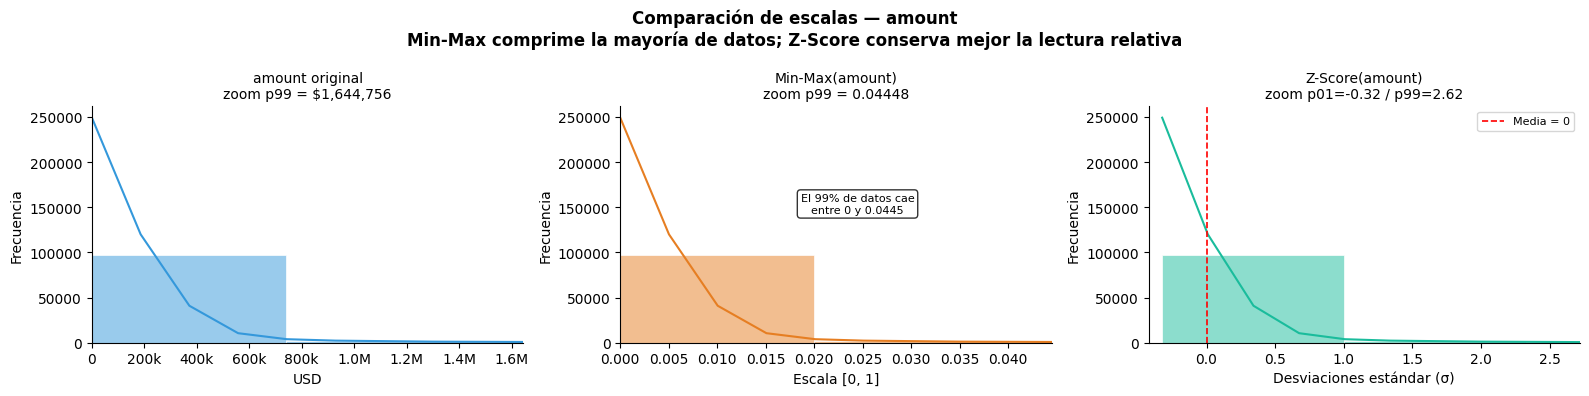

In [19]:
print("4.3 — Comparación de normalización para amount\n")

if 'amount' in df.columns:

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # ── 1. Escala original ───────────────────────────────
    p99_raw = df['amount'].quantile(0.99)

    sns.histplot(
        df['amount'],
        bins=50,
        kde=True,
        ax=axes[0],
        color='#3498db',
        edgecolor='white'
    )

    axes[0].set_xlim(0, p99_raw)
    axes[0].set_title(
        f'amount original\nzoom p99 = ${p99_raw:,.0f}',
        fontsize=10
    )
    axes[0].set_xlabel('USD')
    axes[0].set_ylabel('Frecuencia')

    axes[0].xaxis.set_major_formatter(
        mtick.FuncFormatter(
            lambda x, _: (
                f'{x/1e6:.1f}M'
                if x >= 1e6
                else f'{x/1e3:.0f}k'
                if x >= 1e3
                else f'{x:.0f}'
            )
        )
    )

    # ── 2. Min-Max Scaling ───────────────────────────────
    amount_min = df['amount'].min()
    amount_max = df['amount'].max()

    mm = (df['amount'] - amount_min) / (amount_max - amount_min)

    p99_mm = mm.quantile(0.99)

    sns.histplot(
        mm,
        bins=50,
        kde=True,
        ax=axes[1],
        color='#e67e22',
        edgecolor='white'
    )

    axes[1].set_xlim(0, p99_mm)
    axes[1].set_title(
        f'Min-Max(amount)\nzoom p99 = {p99_mm:.5f}',
        fontsize=10
    )
    axes[1].set_xlabel('Escala [0, 1]')
    axes[1].set_ylabel('Frecuencia')

    axes[1].annotate(
        f'El 99% de datos cae\nentre 0 y {p99_mm:.4f}',
        xy=(p99_mm * 0.55, axes[1].get_ylim()[1] * 0.55),
        ha='center',
        fontsize=8,
        bbox=dict(boxstyle='round', fc='white', alpha=0.8)
    )

    # ── 3. Z-Score ───────────────────────────────────────

    zs = (df['amount'] - df['amount'].mean()) / df['amount'].std()
    p01_zs = zs.quantile(0.01)
    p99_zs = zs.quantile(0.99)

    sns.histplot(
        zs,
        bins=50,
        kde=True,
        ax=axes[2],
        color='#1abc9c',
        edgecolor='white'
    )

    axes[2].set_xlim(p01_zs - 0.1, p99_zs + 0.1)
    axes[2].axvline(
        0,
        color='red',
        linestyle='--',
        linewidth=1.2,
        label='Media = 0'
    )
    axes[2].legend(fontsize=8)

    axes[2].set_title(
        f'Z-Score(amount)\nzoom p01={p01_zs:.2f} / p99={p99_zs:.2f}',
        fontsize=10
    )
    axes[2].set_xlabel('Desviaciones estándar (σ)')
    axes[2].set_ylabel('Frecuencia')

    plt.suptitle(
        'Comparación de escalas — amount\n'
        'Min-Max comprime la mayoría de datos; Z-Score conserva mejor la lectura relativa',
        fontsize=12,
        fontweight='bold'
    )

    plt.tight_layout()
    safe_show('4_3_normalizacion_amount.png')

else:
    print("La columna 'amount' no existe en el DataFrame.")

## 4.4 Distribución de tipos de transacción

Este gráfico muestra qué tipos de transacción dominan la muestra. Es importante porque el fraude no suele repartirse igual entre todos los tipos.


4.4 — Barras de tipos de transacción



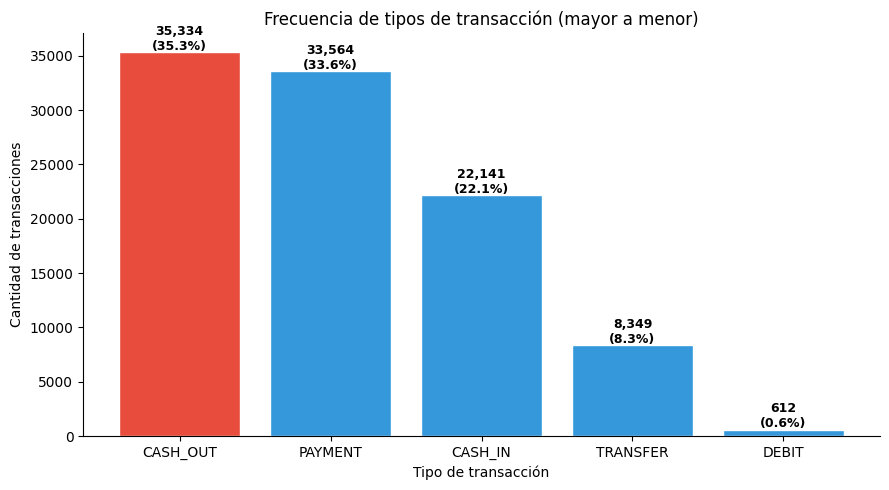

Categoría dominante: CASH_OUT (35.3%)


In [20]:
print("4.4 — Barras de tipos de transacción\n")

frecuencias_type = df['type'].value_counts().sort_values(ascending=False)
pct_dom = frecuencias_type.iloc[0] / frecuencias_type.sum() * 100

fig, ax = plt.subplots(figsize=(9, 5))
colores_type = ['#e74c3c' if i == 0 else '#3498db' for i in range(len(frecuencias_type))]
ax.bar(frecuencias_type.index.astype(str), frecuencias_type.values, color=colores_type, edgecolor='white')
ax.set_title('Frecuencia de tipos de transacción (mayor a menor)', fontsize=12)
ax.set_xlabel('Tipo de transacción')
ax.set_ylabel('Cantidad de transacciones')

for i, v in enumerate(frecuencias_type.values):
    pct_v = v / len(df) * 100
    ax.text(i, v + len(df) * 0.002, f'{v:,}\n({pct_v:.1f}%)', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
safe_show('4_4_barras_tipo.png')
print(f"Categoría dominante: {frecuencias_type.index[0]} ({pct_dom:.1f}%)")


## 4.4b Tasa de fraude por tipo de transacción

Este gráfico complementa al anterior. No basta saber qué tipo aparece más; también importa saber en qué tipo se concentra proporcionalmente el fraude.


4.4b — Tasa de fraude por tipo de transacción



,type,total,fraudes,tasa_fraude
4,TRANSFER,8349,79,0.946221
1,CASH_OUT,35334,62,0.175468
0,CASH_IN,22141,0,0.000000
2,DEBIT,612,0,0.000000
3,PAYMENT,33564,0,0.000000


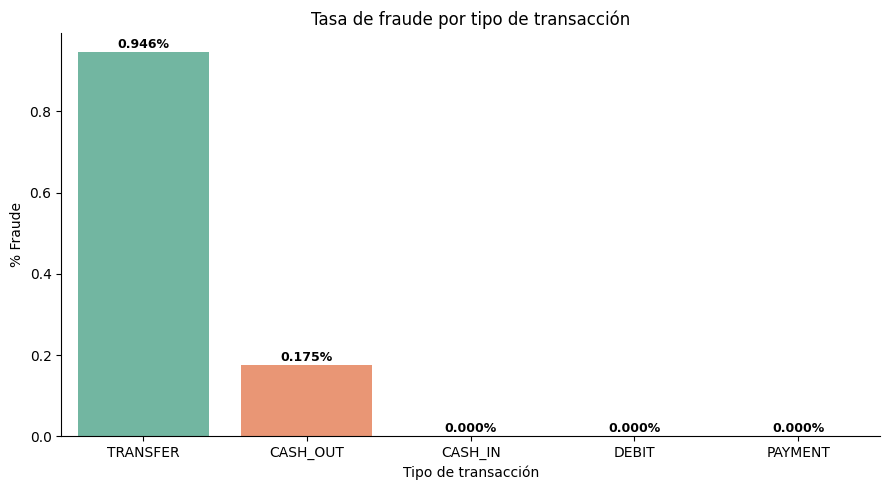


Interpretación:
TRANSFER y CASH_OUT suelen ser los tipos más importantes para analizar fraude,
porque en PaySim los fraudes se concentran principalmente en operaciones de salida o transferencia de fondos.



In [21]:
print("4.4b — Tasa de fraude por tipo de transacción\n")

fraude_tipo = (
    df.groupby('type', observed=True)
    .agg(total=('isFraud', 'count'), fraudes=('isFraud', 'sum'), tasa_fraude=('isFraud', 'mean'))
    .reset_index()
)
fraude_tipo['tasa_fraude'] *= 100
fraude_tipo = fraude_tipo.sort_values('tasa_fraude', ascending=False)
display(fraude_tipo)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=fraude_tipo, x='type', y='tasa_fraude', hue='type', palette='Set2', legend=False, ax=ax)

for i, row in enumerate(fraude_tipo.itertuples()):
    ax.text(i, row.tasa_fraude + 0.01, f'{row.tasa_fraude:.3f}%', ha='center', fontsize=9, fontweight='bold')

ax.set_title('Tasa de fraude por tipo de transacción', fontsize=12)
ax.set_xlabel('Tipo de transacción')
ax.set_ylabel('% Fraude')
plt.tight_layout()
safe_show('4_4b_fraude_por_tipo.png')

print("""
Interpretación:
TRANSFER y CASH_OUT suelen ser los tipos más importantes para analizar fraude,
porque en PaySim los fraudes se concentran principalmente en operaciones de salida o transferencia de fondos.
""")


## 4.5 — Distribución de `amount` separada por `isFraud`

En esta sección se analiza si el monto de la transacción permite diferenciar entre operaciones fraudulentas y no fraudulentas.

Debido a que `amount` tiene una distribución muy sesgada a la derecha, se usa la transformación `log1p(amount)`. Esta transformación comprime los valores extremos y permite visualizar mejor la diferencia entre clases sin eliminar datos.

Primero se presenta la distribución de densidad por clase. Luego se muestra un boxplot para comparar medianas y dispersión entre transacciones fraudulentas y no fraudulentas.


### 4.5a — Densidad de `log1p(amount)` por clase

Este gráfico compara la distribución del monto entre transacciones fraudulentas y no fraudulentas.

La escala logarítmica permite observar con mayor claridad si los fraudes se concentran en montos más altos.

4.5a — Histograma de amount por isFraud con min, max y mediana

Rangos principales de amount por clase:


,isFraud_lbl,cantidad,minimo,mediana,maximo
0,Fraude,141,151.00,580387.06,10000000.00
1,No fraude,99859,0.92,75867.37,36973901.85


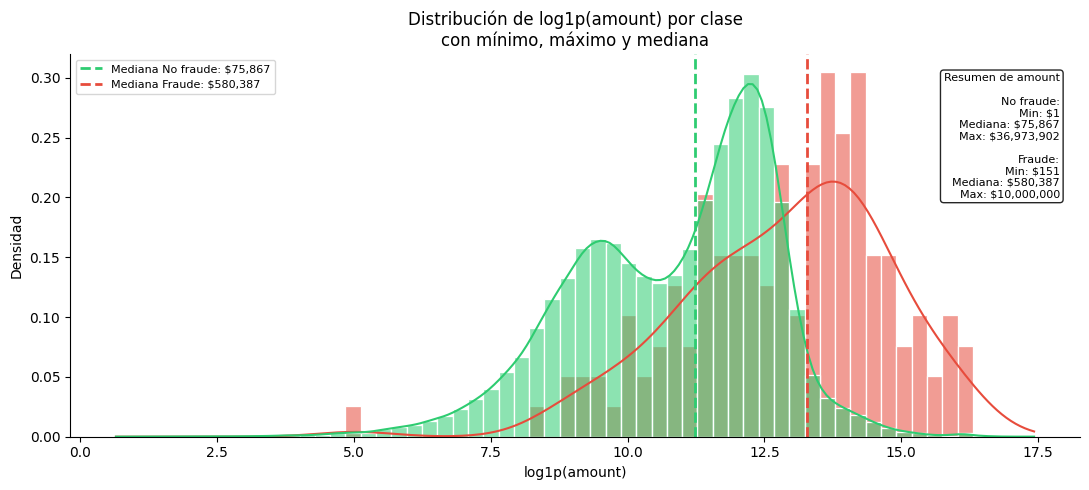

In [22]:
print("4.5a — Histograma de amount por isFraud con min, max y mediana\n")

if 'amount' in df.columns and 'isFraud' in df.columns:

    # Crear columnas auxiliares
    df['amount_log'] = np.log1p(df['amount'])
    df['isFraud_lbl'] = df['isFraud'].map({
        0: 'No fraude',
        1: 'Fraude'
    })

    # Tabla resumen de rangos por clase
    rangos_fraude = (
        df.groupby('isFraud_lbl')['amount']
        .agg(
            cantidad='count',
            minimo='min',
            mediana='median',
            maximo='max'
        )
        .reset_index()
    )

    print("Rangos principales de amount por clase:")
    display(rangos_fraude)

    # Gráfico
    fig, ax = plt.subplots(figsize=(11, 5))

    sns.histplot(
        data=df,
        x='amount_log',
        hue='isFraud_lbl',
        bins=60,
        kde=True,
        stat='density',
        common_norm=False,
        palette={
            'No fraude': '#2ecc71',
            'Fraude': '#e74c3c'
        },
        alpha=0.55,
        edgecolor='white',
        ax=ax
    )

    colores = {
        'No fraude': '#2ecc71',
        'Fraude': '#e74c3c'
    }

    # Líneas de mediana por clase
    for clase in ['No fraude', 'Fraude']:
        datos_clase = df[df['isFraud_lbl'] == clase]['amount']
        mediana = datos_clase.median()

        ax.axvline(
            np.log1p(mediana),
            color=colores[clase],
            linestyle='--',
            linewidth=2,
            label=f'Mediana {clase}: ${mediana:,.0f}'
        )

    # Obtener filas para el cuadro resumen
    no_fraude = rangos_fraude[rangos_fraude['isFraud_lbl'] == 'No fraude'].iloc[0]
    fraude = rangos_fraude[rangos_fraude['isFraud_lbl'] == 'Fraude'].iloc[0]

    # Cuadro con mínimo, mediana y máximo
    texto_rangos = (
        "Resumen de amount\n\n"
        f"No fraude:\n"
        f"Min: ${no_fraude['minimo']:,.0f}\n"
        f"Mediana: ${no_fraude['mediana']:,.0f}\n"
        f"Max: ${no_fraude['maximo']:,.0f}\n\n"
        f"Fraude:\n"
        f"Min: ${fraude['minimo']:,.0f}\n"
        f"Mediana: ${fraude['mediana']:,.0f}\n"
        f"Max: ${fraude['maximo']:,.0f}"
    )

    ax.text(
        0.98,
        0.95,
        texto_rangos,
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(
            boxstyle='round',
            facecolor='white',
            alpha=0.85
        )
    )

    ax.set_title(
        'Distribución de log1p(amount) por clase\n'
        'con mínimo, máximo y mediana',
        fontsize=12
    )

    ax.set_xlabel('log1p(amount)')
    ax.set_ylabel('Densidad')

    ax.legend(fontsize=8, loc='upper left')

    plt.tight_layout()
    safe_show('4_5a_histograma_amount_fraud_min_max_mediana.png')

    # Limpiar columnas auxiliares
    df.drop(
        columns=['amount_log', 'isFraud_lbl'],
        inplace=True,
        errors='ignore'
    )

else:
    print("Faltan las columnas 'amount' o 'isFraud' en el DataFrame.")

### 4.5b — Boxplot de `log1p(amount)` por clase

El boxplot permite comparar la mediana y la dispersión de los montos entre ambas clases.

Además, se anota la mediana real en USD para que la interpretación sea más clara en términos de negocio.

4.5b — Boxplot de amount por isFraud con min, max y mediana

Resumen de amount por clase:


,isFraud_lbl,cantidad,minimo,mediana,maximo
0,No fraude,99859,0.92,75867.37,36973901.85
1,Fraude,141,151.00,580387.06,10000000.00


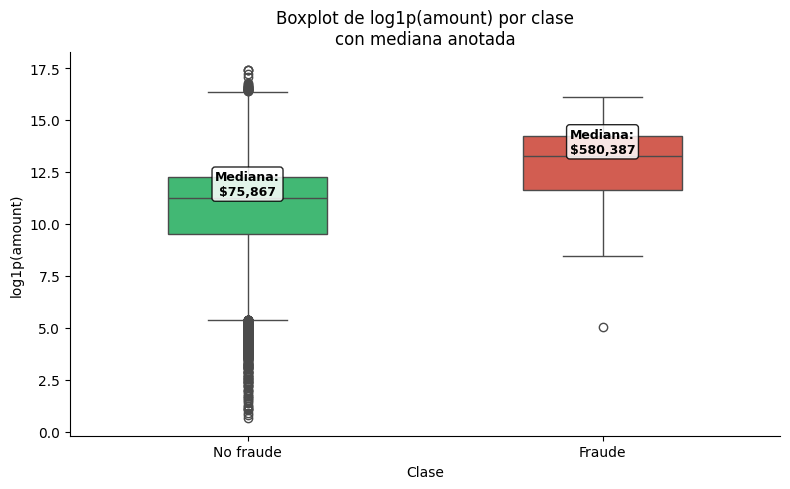

In [24]:
print("4.5b — Boxplot de amount por isFraud con min, max y mediana\n")

if 'amount' in df.columns and 'isFraud' in df.columns:

    df['amount_log'] = np.log1p(df['amount'])
    df['isFraud_lbl'] = df['isFraud'].map({
        0: 'No fraude',
        1: 'Fraude'
    })

    orden_lbl = ['No fraude', 'Fraude']

    resumen_boxplot = (
        df.groupby('isFraud_lbl')['amount']
        .agg(
            cantidad='count',
            minimo='min',
            mediana='median',
            maximo='max'
        )
        .reindex(orden_lbl)
        .reset_index()
    )

    print("Resumen de amount por clase:")
    display(resumen_boxplot)

    fig, ax = plt.subplots(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x='isFraud_lbl',
        y='amount_log',
        order=orden_lbl,
        hue='isFraud_lbl',
        hue_order=orden_lbl,
        palette={
            'No fraude': '#2ecc71',
            'Fraude': '#e74c3c'
        },
        legend=False,
        width=0.45,
        ax=ax
    )

    for i, clase in enumerate(orden_lbl):
        datos_clase = df[df['isFraud_lbl'] == clase]['amount']

        mediana = datos_clase.median()
        mediana_log = np.log1p(mediana)

        ax.text(
            i,
            mediana_log + 0.15,
            f'Mediana:\n${mediana:,.0f}',
            ha='center',
            fontsize=9,
            fontweight='bold',
            bbox=dict(
                boxstyle='round,pad=0.25',
                facecolor='white',
                alpha=0.85
            )
        )

    ax.set_title(
        'Boxplot de log1p(amount) por clase\n'
        'con mediana anotada',
        fontsize=12
    )

    ax.set_xlabel('Clase')
    ax.set_ylabel('log1p(amount)')

    plt.tight_layout()
    safe_show('4_5b_boxplot_amount_fraud_min_max_mediana.png')

    df.drop(
        columns=['amount_log', 'isFraud_lbl'],
        inplace=True,
        errors='ignore'
    )

else:
    print("Faltan las columnas 'amount' o 'isFraud' en el DataFrame.")

## 4.6 Rangos de monto: bajo vs alto

Se crea una variable `amount_categoria` para dividir las transacciones en **Monto Bajo** y **Monto Alto** usando la mediana como corte.

Esto ayuda a ordenar el análisis y permite comparar si el fraude se concentra más en operaciones pequeñas o grandes.


In [25]:
print("4.6 — Rangos de monto: Bajo vs Alto\n")

corte = df['amount'].median()
df['amount_categoria'] = pd.cut(
    df['amount'],
    bins=[0, corte, float('inf')],
    labels=['Monto Bajo', 'Monto Alto'],
    include_lowest=True
)

print(f"Corte aplicado usando la mediana: ${corte:,.2f}\n")
print("Cantidad de transacciones por categoría:")
print(df['amount_categoria'].value_counts())

rango_montos = (
    df.groupby('amount_categoria', observed=True)
    .agg(
        monto_minimo=('amount', 'min'),
        monto_maximo=('amount', 'max'),
        monto_mediano=('amount', 'median'),
        cantidad=('amount', 'count'),
        fraudes=('isFraud', 'sum'),
        tasa_fraude=('isFraud', 'mean')
    )
    .reset_index()
)
rango_montos['tasa_fraude'] *= 100
display(rango_montos)


4.6 — Rangos de monto: Bajo vs Alto

Corte aplicado usando la mediana: $76,030.86

Cantidad de transacciones por categoría:
amount_categoria
Monto Bajo    50000
Monto Alto    50000
Name: count, dtype: int64


,amount_categoria,monto_minimo,monto_maximo,monto_mediano,cantidad,fraudes,tasa_fraude
0,Monto Bajo,0.92,76028.70,13508.195,50000,25,0.050
1,Monto Alto,76033.03,36973901.85,209115.560,50000,116,0.232


### 4.6a KDE detallado por rango de monto

La KDE se separa en una figura propia para que el comportamiento de los montos bajos y altos sea más legible.


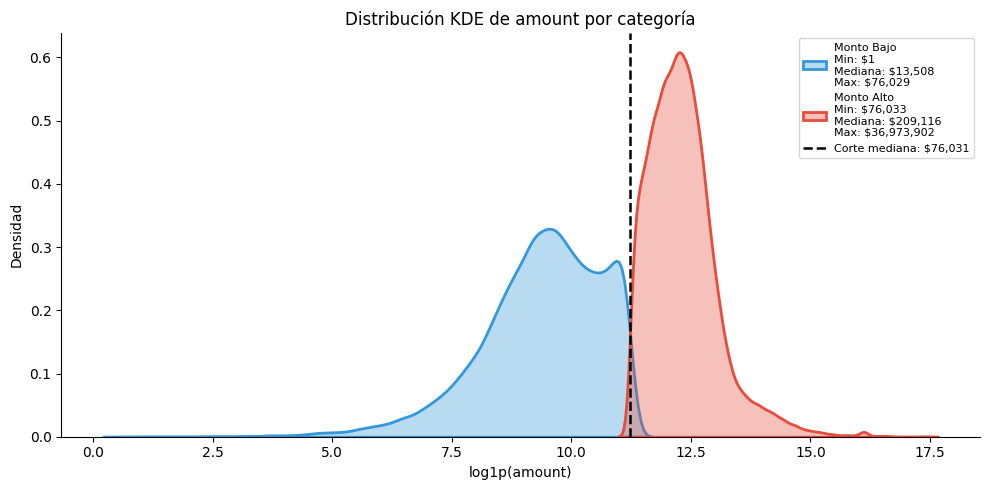

In [ ]:
colores_monto = {'Monto Bajo': '#3498db', 'Monto Alto': '#e74c3c'}

fig, ax = plt.subplots(figsize=(10, 5))

for categoria, grupo in df.groupby('amount_categoria', observed=True):
    monto_min = grupo['amount'].min()
    monto_max = grupo['amount'].max()
    monto_med = grupo['amount'].median()

    sns.kdeplot(
        np.log1p(grupo['amount']),
        ax=ax,
        label=(f"{categoria}\nMin: ${monto_min:,.0f}\nMediana: ${monto_med:,.0f}\nMax: ${monto_max:,.0f}"),
        color=colores_monto[str(categoria)],
        fill=True,
        alpha=0.35,
        linewidth=2
    )

ax.axvline(np.log1p(corte), color='black', linestyle='--', linewidth=1.8, label=f'Corte mediana: ${corte:,.0f}')
ax.set_title('Distribución KDE de amount por categoría')
ax.set_xlabel('log1p(amount)')
ax.set_ylabel('Densidad')
ax.legend(fontsize=8)
plt.tight_layout()
safe_show('4_6a_kde_amount_categoria.png')


### 4.6b Tasa de fraude por rango de monto

Este gráfico responde directamente si los montos altos tienen mayor proporción de fraude que los montos bajos.


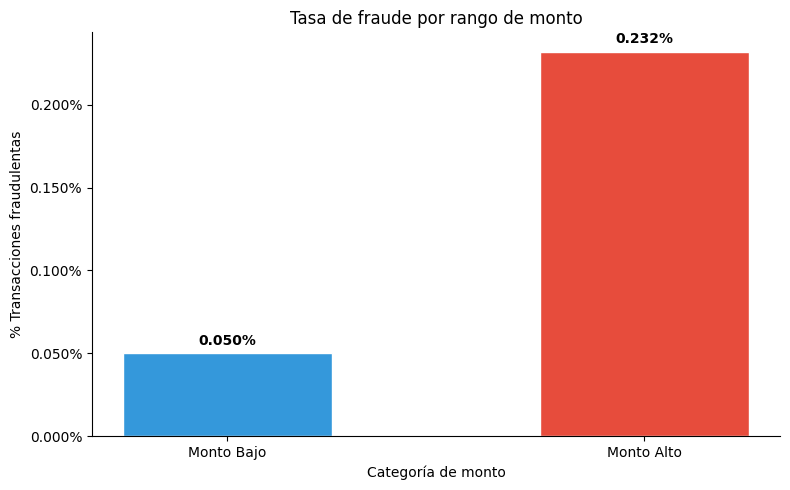


Interpretación:

- Monto Bajo:
  Va desde $0.92 hasta $76,028.70.
  Contiene 50,000 transacciones.
  Fraudes detectados: 25.
  Tasa de fraude: 0.050%.

- Monto Alto:
  Va desde $76,033.03 hasta $36,973,901.85.
  Contiene 50,000 transacciones.
  Fraudes detectados: 116.
  Tasa de fraude: 0.232%.

Conclusión:
La división por rangos permite ordenar el análisis y comparar si el fraude se concentra más en transacciones pequeñas o grandes.



In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    rango_montos['amount_categoria'].astype(str),
    rango_montos['tasa_fraude'],
    color=[colores_monto[str(c)] for c in rango_montos['amount_categoria']],
    edgecolor='white',
    width=0.5
)

for bar, val in zip(bars, rango_montos['tasa_fraude']):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.005, f'{val:.3f}%', ha='center', fontsize=10, fontweight='bold')

ax.set_title('Tasa de fraude por rango de monto')
ax.set_xlabel('Categoría de monto')
ax.set_ylabel('% Transacciones fraudulentas')
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.3f%%'))
plt.tight_layout()
safe_show('4_6b_fraude_por_categoria.png')

bajo = rango_montos[rango_montos['amount_categoria'].astype(str) == 'Monto Bajo'].iloc[0]
alto = rango_montos[rango_montos['amount_categoria'].astype(str) == 'Monto Alto'].iloc[0]

print(f"""
Interpretación:

- Monto Bajo:
  Va desde ${bajo['monto_minimo']:,.2f} hasta ${bajo['monto_maximo']:,.2f}.
  Contiene {int(bajo['cantidad']):,} transacciones.
  Fraudes detectados: {int(bajo['fraudes'])}.
  Tasa de fraude: {bajo['tasa_fraude']:.3f}%.

- Monto Alto:
  Va desde ${alto['monto_minimo']:,.2f} hasta ${alto['monto_maximo']:,.2f}.
  Contiene {int(alto['cantidad']):,} transacciones.
  Fraudes detectados: {int(alto['fraudes'])}.
  Tasa de fraude: {alto['tasa_fraude']:.3f}%.

Conclusión:
La división por rangos permite ordenar el análisis y comparar si el fraude se concentra más en transacciones pequeñas o grandes.
""")


## 4.7 Relación entre tipo de transacción y variables monetarias


1. Heatmap de medias monetarias por tipo de transacción.
2. Boxplot de `amount` por tipo de transacción, ordenado por mediana.


4.7 — Relación entre tipo de transacción y variables monetarias

Estadísticas por tipo de transacción:


amount           oldbalanceOrg            newbalanceOrig  \
              mean    median          mean     median           mean   
type                                                                   
CASH_IN   167892.0  142191.0     3583076.0  1171438.0      3750959.0   
CASH_OUT  175337.0  146441.0       45348.0      590.0        17637.0   
DEBIT       6398.0    2944.0       68355.0    20024.0        64875.0   
PAYMENT    13077.0    9485.0       67152.0    10398.0        60811.0   
TRANSFER  922577.0  497299.0       52351.0        0.0         8193.0   

                    oldbalanceDest            newbalanceDest             
             median           mean     median           mean     median  
type                                                                     
CASH_IN   1339060.0      1560531.0   541239.0      1439129.0   381014.0  
CASH_OUT        0.0      1520843.0   496911.0      1713302.0   699751.0  
DEBIT       14075.0      1412253.0   380973.0      1433712.0   403188.0  
PAYMENT         0.0            0.0        0.0            0.0        0.0  
TRANSFER        0.0      2547106.0  1043159.0      3560486.0  1760817.0

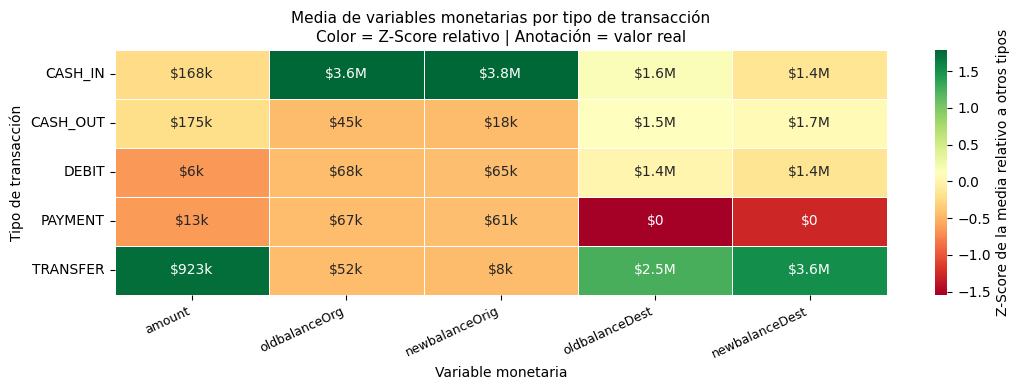

In [ ]:
print("4.7 — Relación entre tipo de transacción y variables monetarias\n")

vars_dinero = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
vars_dinero = [col for col in vars_dinero if col in df.columns]

resumen_type = df.groupby('type', observed=True)[vars_dinero].agg(['mean', 'median']).round(0)
print("Estadísticas por tipo de transacción:")
display(resumen_type)

pivot_mean = df.groupby('type', observed=True)[vars_dinero].mean()
pivot_norm = (pivot_mean - pivot_mean.mean()) / pivot_mean.std()

def fmt_money(x):
    if x >= 1_000_000:
        return f'${x/1_000_000:.1f}M'
    if x >= 1_000:
        return f'${x/1_000:.0f}k'
    return f'${x:.0f}'

# CORREGIDO: antes decía applymap()
annot_df = pivot_mean.map(fmt_money)

fig, ax = plt.subplots(figsize=(11, 4))

sns.heatmap(
    pivot_norm,
    annot=annot_df,
    fmt='',
    cmap='RdYlGn',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Z-Score de la media relativo a otros tipos'}
)

ax.set_title(
    'Media de variables monetarias por tipo de transacción\n'
    'Color = Z-Score relativo | Anotación = valor real',
    fontsize=11
)

ax.set_xlabel('Variable monetaria')
ax.set_ylabel('Tipo de transacción')
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right', fontsize=9)

plt.tight_layout()
safe_show('4_7a_heatmap_type_dinero.png')

### 4.7b Boxplot de monto por tipo de transacción

Este gráfico permite comparar qué tipos de transacción manejan montos más altos. Se ordena por mediana descendente para facilitar la lectura.


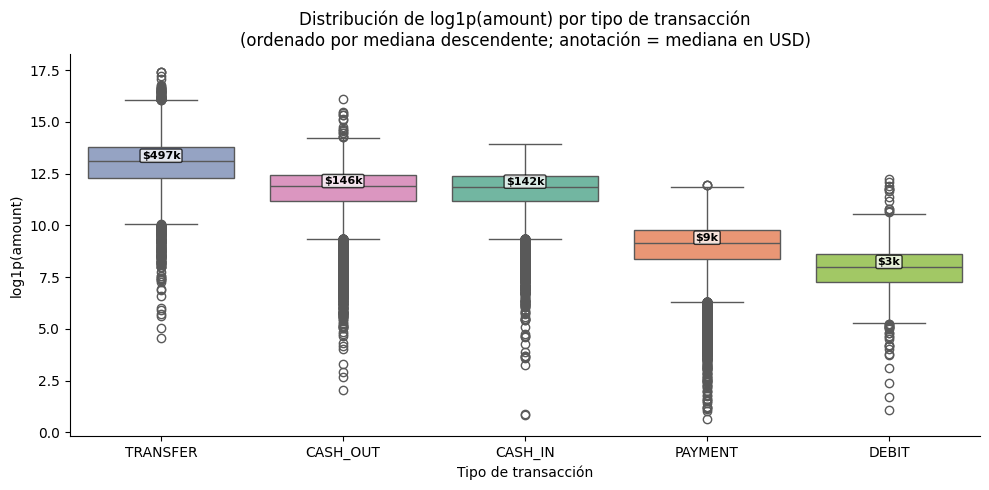


Interpretación:
Los tipos de transacción con mayor mediana de monto merecen mayor atención,
especialmente si además presentan alta tasa de fraude.



In [ ]:
df['amount_log'] = np.log1p(df['amount'])

fig, ax = plt.subplots(figsize=(10, 5))
orden_tipos = df.groupby('type', observed=True)['amount_log'].median().sort_values(ascending=False).index

sns.boxplot(data=df, x='type', y='amount_log', hue='type', order=orden_tipos, palette='Set2', legend=False, ax=ax)

for i, tipo in enumerate(orden_tipos):
    med_usd = df[df['type'] == tipo]['amount'].median()
    med_log = np.log1p(med_usd)
    ax.text(i, med_log + 0.1, f'${med_usd/1_000:.0f}k', ha='center', fontsize=8, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.75))

ax.set_title('Distribución de log1p(amount) por tipo de transacción\n(ordenado por mediana descendente; anotación = mediana en USD)', fontsize=12)
ax.set_xlabel('Tipo de transacción')
ax.set_ylabel('log1p(amount)')
plt.tight_layout()
safe_show('4_7b_boxplot_type_amount.png')

df.drop(columns=['amount_log'], inplace=True)

print("""
Interpretación:
Los tipos de transacción con mayor mediana de monto merecen mayor atención,
especialmente si además presentan alta tasa de fraude.
""")


### 4.8. Patrón de vaciado de cuenta

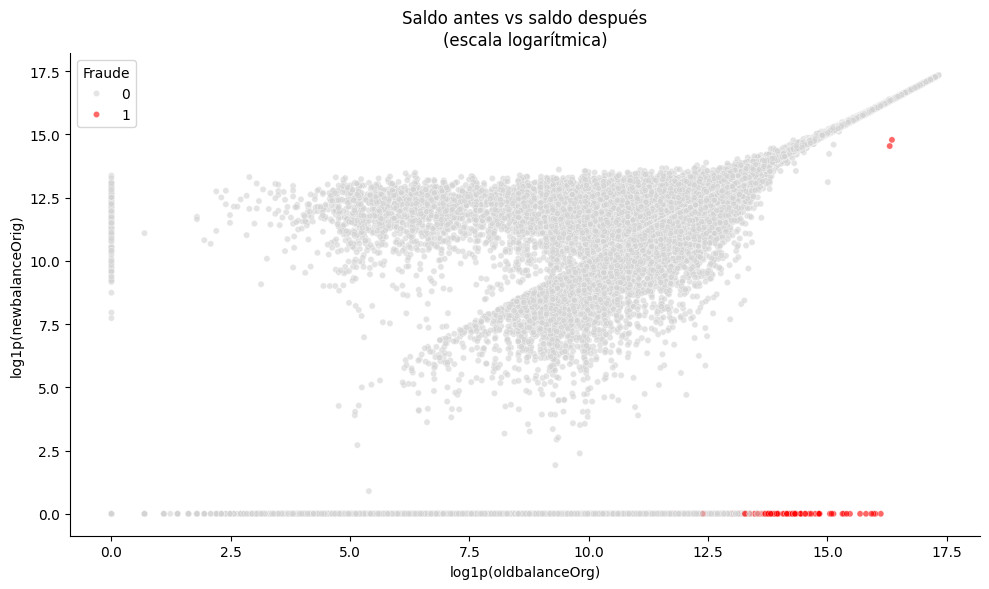

In [ ]:
sample = df.copy()

sample['oldbalanceOrg_log'] = np.log1p(sample['oldbalanceOrg'])
sample['newbalanceOrig_log'] = np.log1p(sample['newbalanceOrig'])

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=sample,
    x='oldbalanceOrg_log',
    y='newbalanceOrig_log',
    hue='isFraud',
    palette={0:'lightgray',1:'red'},
    alpha=0.6,
    s=20
)

plt.title(
    'Saldo antes vs saldo después\n'
    '(escala logarítmica)'
)

plt.xlabel('log1p(oldbalanceOrg)')
plt.ylabel('log1p(newbalanceOrig)')

plt.legend(title='Fraude')
plt.tight_layout()
plt.show()


El gráfico revela una separación clara entre transacciones fraudulentas y legítimas. Los casos de fraude se concentran casi exclusivamente en tomas donde el saldo de la cuenta posterior a la trnasaccoin es cero, indicando un patrón consistente de vaciado completo de fondos. En contraste, las transacciones legítimas presentan una distribución mucho más dispersa y suelen conservar parte del saldo original. Este comportamiento sugiere que las variables oldbalanceOrg y especialmente newbalanceOrig poseen un alto poder discriminante para la detección de fraude

# 5. Hallazgos principales

1. La variable `isFraud` está altamente desbalanceada, por lo que accuracy no sería una métrica confiable para un modelo futuro.
2. El fraude se concentra principalmente en tipos de transacción asociados a salida de dinero, especialmente `TRANSFER` y `CASH_OUT`.
3. Las transacciones fraudulentas presentan montos más altos que las no fraudulentas.
4. Las variables `oldbalanceOrg`, `newbalanceOrig` y `amount` muestran alta variabilidad relativa, lo que indica patrones financieros heterogéneos.
5. La relación entre monto y saldo previo del originador puede ser más útil que usar solamente el monto absoluto.

## 6 Limitaciones del análisis

1. **Dataset sintético:** PaySim es una simulación basada en datos reales de M-Pesa (Kenya). Sus patrones de fraude son representativos pero no idénticos a escenarios reales de banca móvil en otros mercados.

2. **Muestra reducida:** Se trabajó con 100,000 registros de un total de 6.3 millones. En esa muestra, los casos de fraude son aproximadamente 130, lo que limita la estabilidad estadística de cualquier estimación sobre la clase minoritaria.

3. **Desbalance extremo de clases:**  Con solo ~0.13% de fraude, métricas como accuracy son engañosas. Un modelo que prediga siempre "no fraude" obtendría >99% de accuracy sin detectar ningún fraude real.

4. **Variable temporal `step` eliminada:** Se descartó por no ser relevante para el análisis de comportamiento financiero, pero podría contener patrones temporales de fraude que no fueron explorados.